In [1]:
# get Iris
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data
y = iris.target

In [17]:
from sklearn.cluster import DBSCAN

# Build DBSCAN model
dbscan = DBSCAN(eps=0.5, min_samples=5)

labels = dbscan.fit_predict(X)

print(labels.shape)
print(labels[:10])

print("Cluster memberships:")
print(labels)

# Number of clusters found (excluding noise points labeled as -1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("\nNumber of clusters found:")
print(n_clusters)

print("\nCluster labels:")
print(set(labels))

(150,)
[0 0 0 0 0 0 0 0 0 0]
Cluster memberships:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1  1 -1  1  1 -1  1  1  1  1  1  1  1 -1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1
  1  1 -1  1  1  1  1  1  1 -1 -1  1 -1 -1  1  1  1  1  1  1  1 -1 -1  1
  1  1 -1  1  1  1  1  1  1  1  1 -1  1  1 -1 -1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1]

Number of clusters found:
2

Cluster labels:
{np.int64(0), np.int64(1), np.int64(-1)}


In [15]:
import numpy as np

unique, counts = np.unique(y, return_counts=True)

for labels, count in zip(unique, counts):
    print(f"{iris.target_names[labels]}: {count}")

most_common = unique[np.argmax(counts)]
print("\nMost occurring flower:", iris.target_names[most_common])

setosa: 50
versicolor: 50
virginica: 50

Most occurring flower: setosa


In [16]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("labels shape:", labels.shape)
print("Unique y:", np.unique(y))
print("Unique labels:", np.unique(labels))

X shape: (150, 4)
y shape: (150,)
labels shape: ()
Unique y: [0 1 2]
Unique labels: [2]


In [18]:
# Confusion Matrix
import pandas as pd
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, labels)

print(cm)

# Nicely formatted
cm_df = pd.DataFrame(cm)
print(cm_df)



[[ 0  0  0  0]
 [ 1 49  0  0]
 [ 6  0 44  0]
 [10  0 40  0]]
    0   1   2  3
0   0   0   0  0
1   1  49   0  0
2   6   0  44  0
3  10   0  40  0


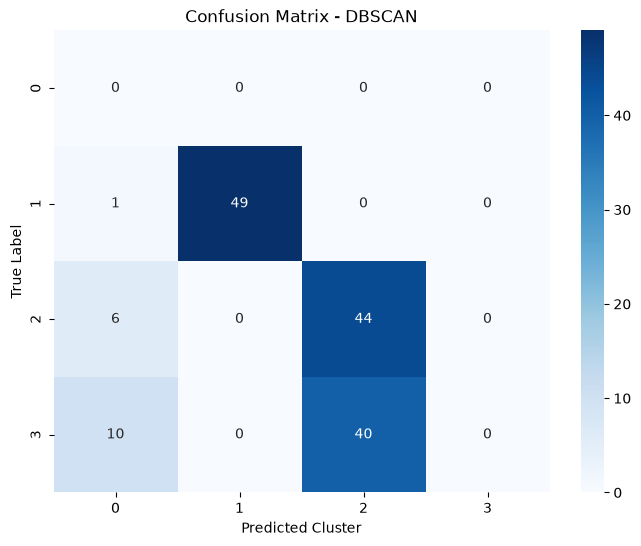

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True
)

plt.title('Confusion Matrix - DBSCAN')
plt.xlabel('Predicted Cluster')
plt.ylabel('True Label')
plt.show()

In [22]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, labels)
print("Accuracy:", accuracy)

Accuracy: 0.62


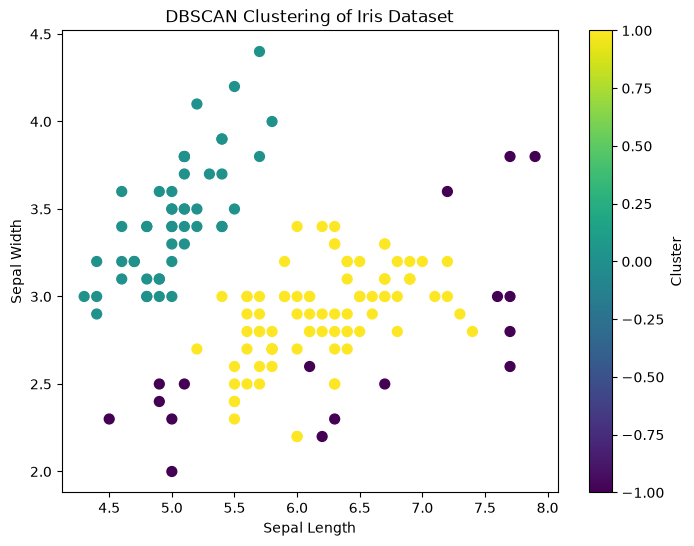

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X[:, 0],  # Sepal Length
    X[:, 1],  # Sepal Width
    c=labels,
    cmap='viridis',
    s=50
)

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('DBSCAN Clustering of Iris Dataset')
plt.colorbar(scatter, label='Cluster')
plt.show()

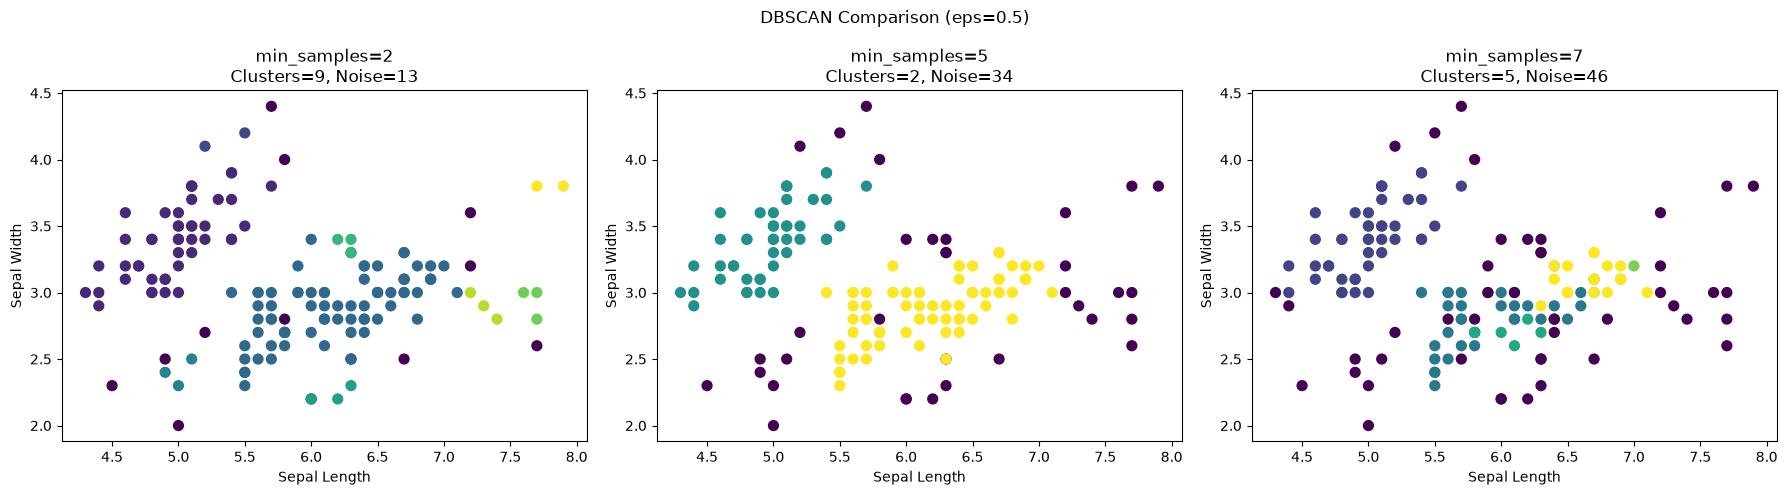

In [25]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Standardize data
X_scaled = StandardScaler().fit_transform(X)

min_samples_values = [2, 5, 7]
eps = 0.5

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, min_samples in zip(axes, min_samples_values):

    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    scatter = ax.scatter(
        X[:, 0],
        X[:, 1],
        c=labels,
        cmap='viridis',
        s=50
    )

    ax.set_title(
        f'min_samples={min_samples}\nClusters={n_clusters}, Noise={n_noise}'
    )
    ax.set_xlabel('Sepal Length')
    ax.set_ylabel('Sepal Width')

plt.suptitle(f'DBSCAN Comparison (eps={eps})')
plt.tight_layout()
plt.show()

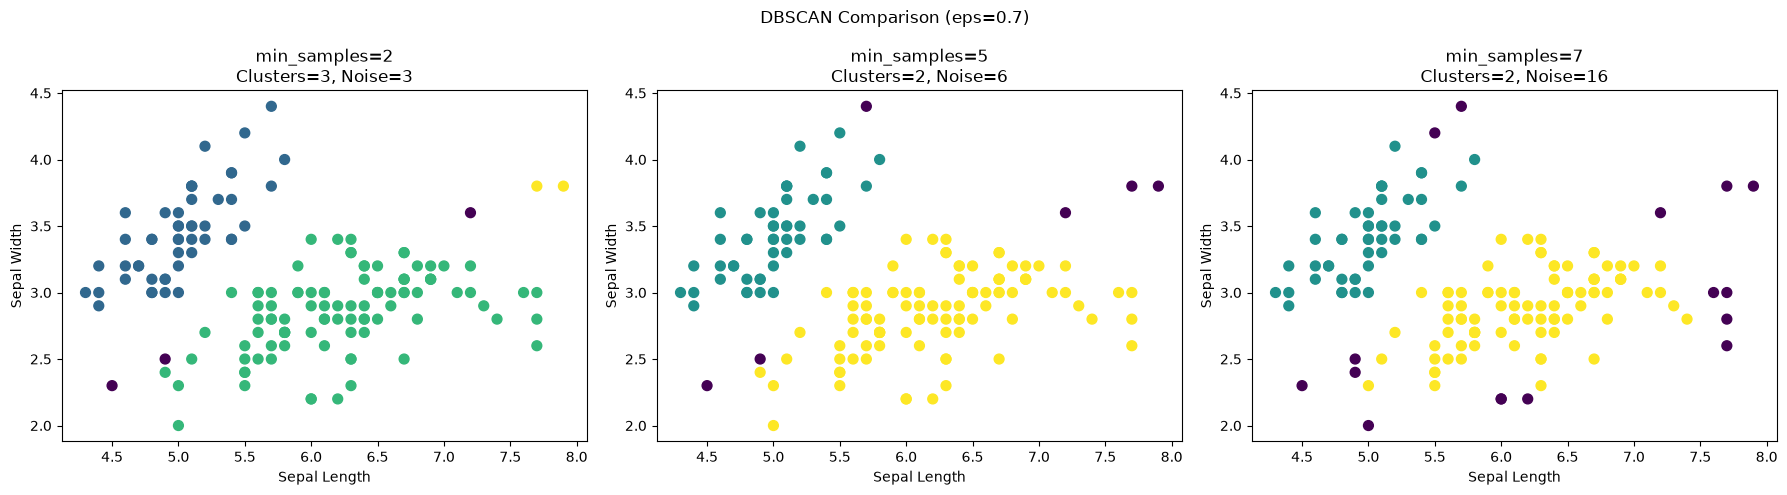

In [26]:
min_samples_values = [2, 5, 7]
eps = 0.7

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, min_samples in zip(axes, min_samples_values):

    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    scatter = ax.scatter(
        X[:, 0],
        X[:, 1],
        c=labels,
        cmap='viridis',
        s=50
    )

    ax.set_title(
        f'min_samples={min_samples}\nClusters={n_clusters}, Noise={n_noise}'
    )
    ax.set_xlabel('Sepal Length')
    ax.set_ylabel('Sepal Width')

plt.suptitle(f'DBSCAN Comparison (eps={eps})')
plt.tight_layout()
plt.show()

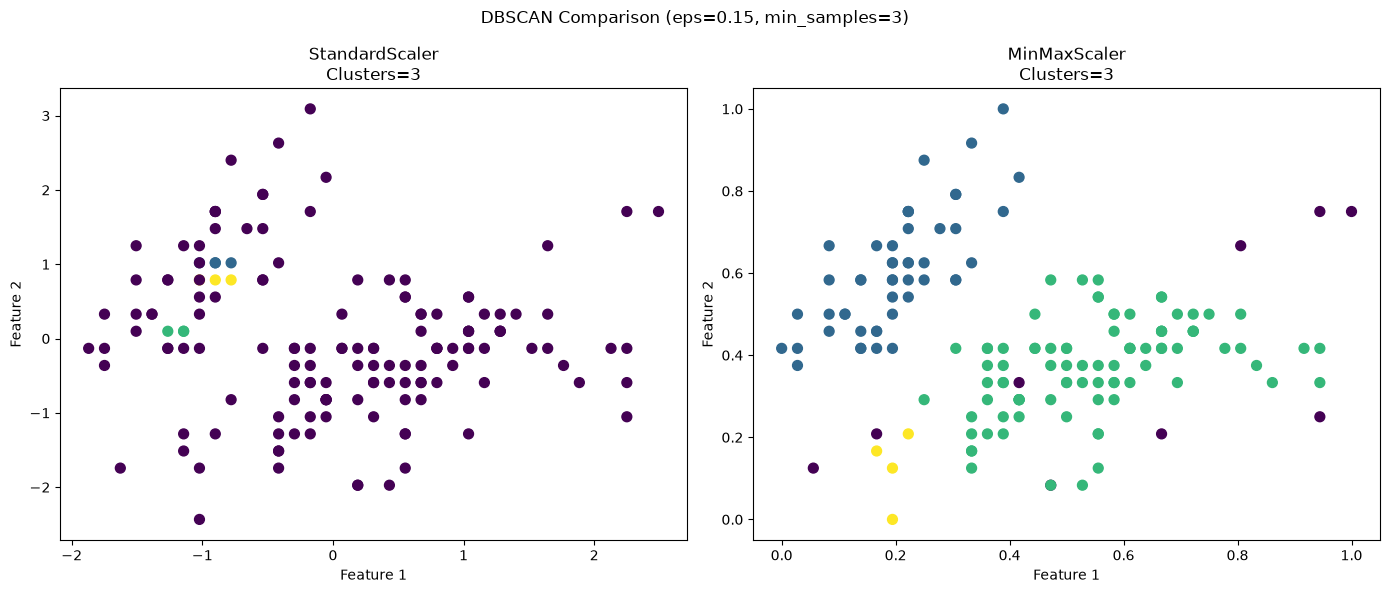

In [32]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt

# Scale data
X_standard = StandardScaler().fit_transform(X)
X_minmax = MinMaxScaler().fit_transform(X)

# DBSCAN parameters
eps = 0.15
min_samples = 3

# Fit DBSCAN
labels_standard = DBSCAN(
    eps=eps,
    min_samples=min_samples
).fit_predict(X_standard)

labels_minmax = DBSCAN(
    eps=eps,
    min_samples=min_samples
).fit_predict(X_minmax)

# Number of clusters
clusters_standard = len(set(labels_standard)) - (1 if -1 in labels_standard else 0)
clusters_minmax = len(set(labels_minmax)) - (1 if -1 in labels_minmax else 0)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# StandardScaler
axes[0].scatter(
    X_standard[:, 0],
    X_standard[:, 1],
    c=labels_standard,
    cmap='viridis',
    s=50
)
axes[0].set_title(
    f'StandardScaler\nClusters={clusters_standard}'
)
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# MinMaxScaler
axes[1].scatter(
    X_minmax[:, 0],
    X_minmax[:, 1],
    c=labels_minmax,
    cmap='viridis',
    s=50
)
axes[1].set_title(
    f'MinMaxScaler\nClusters={clusters_minmax}'
)
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.suptitle(
    f'DBSCAN Comparison (eps={eps}, min_samples={min_samples})'
)
plt.tight_layout()
plt.show()